In [9]:
import tensorflow as tf
import numpy as np
import time

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, precision_score, recall_score, accuracy_score


#### **1. Dataset Preprocessing**


In [10]:
dataset_path = "face_mask"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 270 images belonging to 2 classes.
Found 67 images belonging to 2 classes.


#### **2.Load Pretrained MobileNetV2 and Add Classification Layers**

In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

#### **3.Compile and Train**

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.6370 - loss: 0.6418 - precision_1: 0.5341 - recall_1: 0.4519 - val_accuracy: 0.7910 - val_loss: 0.4624 - val_precision_1: 0.9286 - val_recall_1: 0.5000
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8481 - loss: 0.4000 - precision_1: 0.9200 - recall_1: 0.6635 - val_accuracy: 0.9104 - val_loss: 0.3214 - val_precision_1: 0.8571 - val_recall_1: 0.9231
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9111 - loss: 0.2805 - precision_1: 0.8774 - recall_1: 0.8942 - val_accuracy: 0.9254 - val_loss: 0.2797 - val_precision_1: 0.9200 - val_recall_1: 0.8846
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9519 - loss: 0.1902 - precision_1: 0.9417 - recall_1: 0.9327 - val_accuracy: 0.9254 - val_loss: 0.2173 - val_precision_1: 0.9200 - val_recall_1: 0.8846
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9519 - loss: 0.1793 - precision_1: 0.9691 - recall_1: 0.9038 - val_accuracy: 0.9403 - v

#### **4.Evaluation and Inference Speed**

In [14]:
predictions = model.predict(validation_generator)

predictions = (predictions > 0.5).astype(int)

y_true = validation_generator.classes

accuracy = accuracy_score(y_true,predictions)
precision = precision_score(y_true,predictions)
recall = recall_score(y_true,predictions)

print("\nEvaluation Results")
print("----------------------------")
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)

print(classification_report(y_true,predictions))

sample = np.expand_dims(
    next(iter(validation_generator))[0][0],
    axis=0
)

runs = 100

start = time.time()

for i in range(runs):
    model.predict(sample, verbose=0)

end = time.time()

avg_time = (end-start)/runs

print("\nAverage Inference Time")
print(avg_time,"seconds/image")

print("FPS =",1/avg_time)

model.save("FaceMask_MobileNetV2.keras")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 712ms/step

Evaluation Results
----------------------------
Accuracy : 0.9253731343283582
Precision: 0.8620689655172413
Recall   : 0.9615384615384616
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        41
           1       0.86      0.96      0.91        26

    accuracy                           0.93        67
   macro avg       0.92      0.93      0.92        67
weighted avg       0.93      0.93      0.93        67


Average Inference Time
0.13420454502105714 seconds/image
FPS = 7.45131247114691


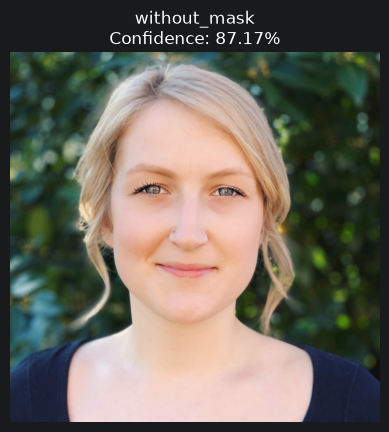

Prediction : without_mask
Confidence : 87.17%


In [8]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Trained Model
# -------------------------------

model = tf.keras.models.load_model(
    "FaceMask_MobileNetV2.keras",
    compile=False
)

# -------------------------------
# 2. Define Class Names
# -------------------------------
# Change the order if your class_indices are different.
# Check using: print(train_generator.class_indices)

class_names = ['with_mask', 'without_mask']

# -------------------------------
# 3. Load Test Image
# -------------------------------

image_path = "No Mask5.jpg"     # Replace with your image

img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError("Image not found!")

# Convert BGR to RGB for displaying
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize for MobileNetV2
img_resized = cv2.resize(img_rgb, (224, 224))

# Normalize
img_normalized = img_resized.astype("float32") / 255.0

# Add batch dimension
img_input = np.expand_dims(img_normalized, axis=0)

# -------------------------------
# 4. Predict
# -------------------------------

prediction = model.predict(img_input, verbose=0)

probability = prediction[0][0]

# -------------------------------
# 5. Convert Probability to Class
# -------------------------------

if probability >= 0.5:
    predicted_class = class_names[1]
    confidence = probability
else:
    predicted_class = class_names[0]
    confidence = 1 - probability

# -------------------------------
# 6. Display Results
# -------------------------------

plt.imshow(img_rgb)
plt.title(f"{predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()

print("="*40)
print("Prediction :", predicted_class)
print(f"Confidence : {confidence*100:.2f}%")
print("="*40)